# Test JSBSim computations of rotations against the exact solution

This notebook aims to assess the fidelity of JSBSim with regard to the computaion of the vehicle rotation. For that purpose, in this notebok, the exact solution of the free rigid body rotation of a top is computed by JSBSim and compared the exact solution.

The exact solution is evaluated using the program `data/free_rigid_body_rotations.c` in the folder `data`. The program comes from the paper *Numerical implementation of the exact rigid dynamics of free rigid bodies*, van Zon R., Schofield J., 2006.

For the evaluation, we are assuming that the vehicle is a top which principal inertias are $I_{xx}=10$, $I_{yy}=20$ and $I_{zz}=26$. The initial value for the rotation rates are $\omega_x=1$, $\omega_y=15$ and $\omega_z=1$. No torques are applied, the movement is one of a free rigid body.

The exact solutions of this problem are Jacobi elliptic functions which are very smooth so on which the classical algorithms (Euler, Adams-Bashforth) are expected to perform well.

Please note that:
1. The values are hardcoded in the program `data/free_rigid_body_rotations.c`. For different values to be tested, the code in `free_rigid_body_rotations.c` should be modified and re-run to update the CSV file `data/top.csv`. If the inertias are modified in `data/free_rigid_body_rotations.c`, make sure that they are modified accordingly on `data/top.xml`.
2. The rotation rate $\omega_y=15$ is unrealistic for most aircraft applications, including fighter jets and aerobatics. These values are meant to stress the algorithm of JSBSim and exacerbate its errors.

In [1]:
# Confirm that JSBSim is installed. If not and running on Google Colab
# then install JSBSim into the Google Colab instance.

import os

try:
  import jsbsim
  print('JSBSim is installed')
  print(f'Current working directory: {os.getcwd()}')
except ImportError:
  import sys
  if 'google.colab' in sys.modules:
      print('Installing JSBSim...')
      !pip install jsbsim
  else:
    sys.path.append('../../build/Debug/tests')
    import jsbsim

## Code to evaluate rotation rates

### Imports and enumerations

In this cell, we define an enumeration for the various ODE integration methods available in JSBSim.

In [2]:
import enum

class ODE_methods(enum.IntEnum):
    NONE = 0
    EULER = 1
    TRAPEZOIDAL = 2
    ADAMS_BASHFORTH2 = 3
    ADAMS_BASHFORTH3 = 4
    ADAMS_BASHFORTH4 = 5
    BUSS1 = 6
    BUSS2 = 7
    LOCAL_LINEARIZATION = 8
    ADAMS_BASHFORTH5 = 9

method_names = ["None", "Euler", "Trapezoidal", "Adams-BashForth 2", "Adams-BashForth 3",
                "Adams-BashForth 4", "Buss 1", "Buss 2", "Local linearization",
                "Adams-BashForth 5"]

### Data structure for simulation results

We define a `SimulationResults` dataclass to store the output of the multiple simulations. This allows for easy sharing of data between the computation function and the plotting functions.

In [3]:
from dataclasses import dataclass

@dataclass
class SimulationResults:
    methods: tuple
    times: np.ndarray
    p: np.ndarray
    q: np.ndarray
    r: np.ndarray
    roll: np.ndarray
    pitch: np.ndarray
    yaw: np.ndarray

### Exact solution preparation

We load the exact solution from `data/top.csv` and compute the corresponding Euler angles to serve as a reference for our integration methods.

In [4]:
import numpy as np
import pandas as pd
from scipy.spatial.transform import Rotation as R

# Load the exact resolution of the free rigid body rotation
exact = pd.read_csv('data/top.csv', header=None, sep='\\s+')

nvalues = len(exact.iloc[:,0])
freq_exact = int(nvalues / exact.iloc[-1,0])
t_final = nvalues / freq_exact

# Compute the Euler angles of the exact solution
# - Columns 4 to 12 contain the Ti2b matrix values
# - Ti2b is the transform matrix from inertial frame to the body frame
Ti2b_data = exact.iloc[:, 4:13].values # Extract the data of matrices (one per time step)
Ti2b = Ti2b_data.reshape(-1, 3, 3)
rotations = R.from_matrix(Ti2b)
euler_angles = rotations.as_euler('zyx', degrees=False)
# In JSBSim, Euler angles measure the body attitude with respect to the inertial frame
# so we need to change the sign of the Euler angles from the exact computation.
exact[13] = -euler_angles[:, 2] # Roll
exact[14] = -euler_angles[:, 1] # Pitch
exact[15] = -euler_angles[:, 0] # Yaw
# In JSBSim, yaw is measuring the heading from 0 (North) to 2pi
exact[15] = exact[15] % (2.0*np.pi)

# Avoid flooding messages
jsbsim.FGJSBBase().debug_lvl = 0  # Disable debug introspection.
jsbsim.get_logger().set_min_level(jsbsim.LogLevel.WARN)  # Ignore info messages

### Simulation function

This function iterates over a list of methods and frequencies, runs the JSBSim simulation for each, and stores the results in a `SimulationResults` object.

In [5]:
def run_rotations_simulations(methods, t_final):
    nsteps = max([int(m[2]*t_final) for m in methods])
    n_methods = len(methods)

    results = SimulationResults(
        methods=methods,
        times=np.empty((n_methods, nsteps)),
        p=np.empty((n_methods, nsteps)),
        q=np.empty((n_methods, nsteps)),
        r=np.empty((n_methods, nsteps)),
        roll=np.empty((n_methods, nsteps)),
        pitch=np.empty((n_methods, nsteps)),
        yaw=np.empty((n_methods, nsteps))
    )

    for j, method in enumerate(methods):
        fdm = jsbsim.FGFDMExec(".")
        fdm.set_aircraft_path('data')
        fdm.load_model('top', False)
        fdm.set_dt(1.0/float(method[2]))
        fdm['ic/p-rad_sec'] = 1.0
        fdm['ic/q-rad_sec'] = 15.0
        fdm['ic/r-rad_sec'] = 1.0
        fdm['ic/phi-rad'] = 0.0
        fdm['ic/theta-rad'] = 0.0
        fdm['ic/psi-true-rad'] = 0.0
        fdm['simulation/integrator/position/rotational'] = method[0]
        fdm['simulation/integrator/rate/rotational'] = method[1]
        fdm.run_ic()

        for i in range(nsteps):
            results.times[j, i] = fdm.get_sim_time()
            results.p[j, i] = fdm['velocities/p-rad_sec']
            results.q[j, i] = fdm['velocities/q-rad_sec']
            results.r[j, i] = fdm['velocities/r-rad_sec']
            results.roll[j, i] = fdm['attitude/roll-rad']
            results.pitch[j, i] = fdm['attitude/pitch-rad']
            results.yaw[j, i] = fdm['attitude/psi-rad']
            fdm.run()

    return results

### Plotting rotation rates

This function visualizes the rotation rates (p, q, r) for each integration method compared to the exact solution.

In [6]:
import matplotlib.pyplot as plt

def plot_rotation_rates(results, exact_data, *, time_range=(0, t_final), y_range=None,
                        name_col=0, n_points_exact=None):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    for i in range(len(results.methods)):
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"
        ax1.plot(results.times[i, :], results.p[i, :], label=label)
        ax2.plot(results.times[i, :], results.q[i, :], label=label)
        ax3.plot(results.times[i, :], results.r[i, :], label=label)

    if n_points_exact is None:
        freq = 1
    else:
        time_span = time_range[1] - time_range[0]
        freq = max(1, int(freq_exact * time_span / n_points_exact))

    ax1.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 1], '+', label='Exact')
    ax2.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 2], '+', label='Exact')
    ax3.plot(exact_data.iloc[::freq, 0], exact_data.iloc[::freq, 3], '+', label='Exact')

    for ax, title in zip((ax1, ax2, ax3), ('p', 'q', 'r')):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_xlim(time_range)
        if y_range is not None:
            ax.set_ylim(y_range)
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad/s")
    plt.show()

### Plotting rotation rate errors

This function calculates and displays the error between the simulated rotation rates and the exact solution reference.

In [23]:
def plot_rotation_rate_errors(results, exact_data, *, time_range=(0, t_final),
                            y_range=None, name_col=0):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    nvalues = len(exact_data)

    for i in range(len(results.methods)):
        step = int(results.methods[i][2] / freq_exact)
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"

        ax1.plot(exact_data.iloc[:, 0], results.p[i, :step*nvalues:step] - exact_data.iloc[:, 1], label=label)
        ax2.plot(exact_data.iloc[:, 0], results.q[i, :step*nvalues:step] - exact_data.iloc[:, 2], label=label)
        ax3.plot(exact_data.iloc[:, 0], results.r[i, :step*nvalues:step] - exact_data.iloc[:, 3], label=label)

    for ax, title in zip((ax1, ax2, ax3), ("p error", "q error", "r error")):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.set_xlim(time_range)
        if y_range is not None:
            ax.set_ylim(y_range)
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad/s")
    plt.show()

## Rotation Rates

### Trapezoidal Method

We will start investigating the *trapezoidal* method that JSBSim provides. This method is not a classical ODE (Ordinary Differential Equations) method, it is not listed in the textbooks about Numerical Analysis so it seems to be unique to JSBSim. Let's see how it compares to the good old Euler method.

For this first investigation, we will use a time step of 120Hz (i.e. 120 steps par second) which is the default time step for JSBSim. The method of Adams-Bashforth of the 5th order will be used to compute the Euler angles assuming that it gives maximum accuracy such that the angular rates precision will be primarily driven by their own integration method.

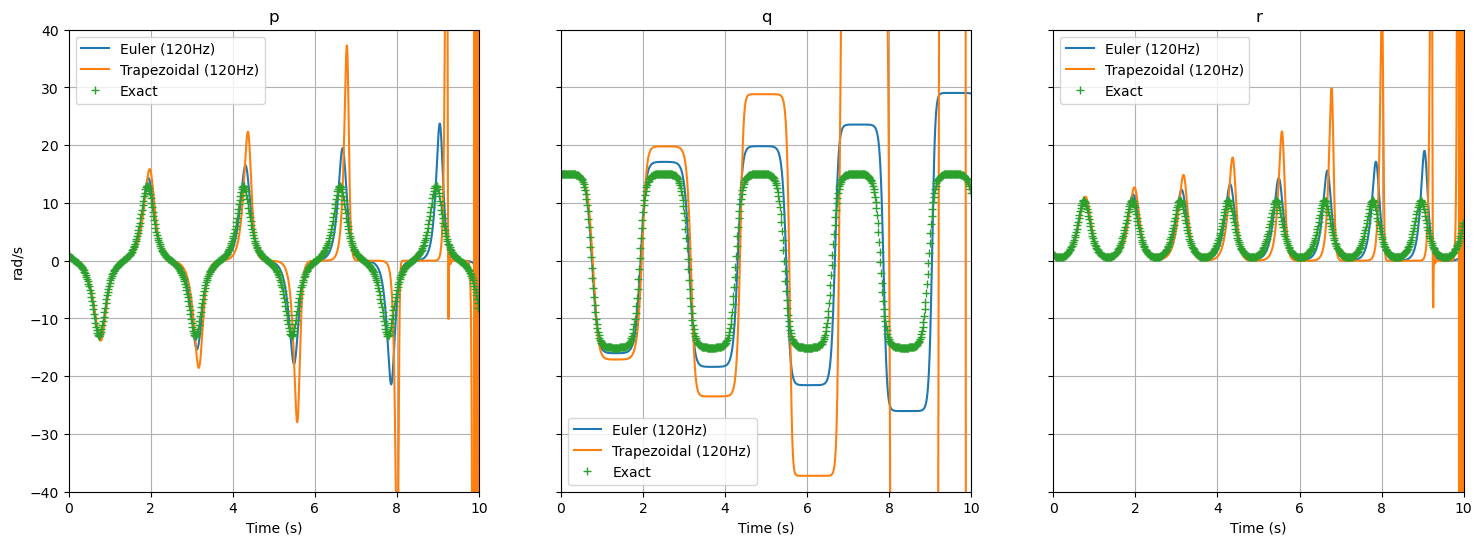

In [11]:

integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.EULER, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.TRAPEZOIDAL, 120))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rates(results, exact, y_range=(-40,40), name_col=1)

#### Assessing the Order of the Trapezoidal Method

##### Observation

Numerical results indicate that the error associated with the trapezoidal method accumulates significantly faster than that of the Euler method, eventually leading to divergence before the 10-second simulation mark. This suboptimal performance warrants a formal analysis of the method's consistency order.

##### Mathematical Framework

Consider the initial value problem (IVP):

$$\dot{y} = f(t, y), \quad y(t_0) = y_0$$

where $f \in \mathcal{C}^1([t_0, t_0+T] \times \mathbf{R}, \mathbf{R})$. Let $z(t)$ denote the exact solution. For a uniform discretization with step size $h$, we define $t_n = t_0 + nh$. The local truncation error $\tau_{n+1}$ is defined as the difference between the exact solution $z(t_{n+1})$ and the numerical approximation $y_{n+1}$, assuming all prior values are exact (i.e., $y_k = z(t_k)$ for $k \le n$).

##### Error Analysis of the JSBSim Trapezoidal Scheme

The trapezoidal method implemented in JSBSim employs the following explicit update rule:

$$y_{n+1} = y_n + \frac{h}{2} \left( f_n + f_{n-1} \right)$$

Under the assumption that $y_n = z(t_n)$ and $y_{n-1} = z(t_{n-1})$, we expand $z(t_{n+1})$ and $f_{n-1} = z'(t_n - h)$ using Taylor series around $t_n$:

$$z(t_{n+1}) = z(t_n) + h z'(t_n) + \frac{h^2}{2} z''(t_n) + \mathcal{O}(h^3)$$
$$f_{n-1} = z'(t_n) - h z''(t_n) + \mathcal{O}(h^2)$$

Substituting these expressions into the definition of the local truncation error:

$$\tau_{n+1} = z(t_{n+1}) - \left[ z(t_n) + \frac{h}{2}(z'(t_n) + f_{n-1}) \right]$$
$$\tau_{n+1} = \left[ z(t_n) + h z'(t_n) + \frac{h^2}{2} z''(t_n) \right] - \left[ z(t_n) + \frac{h}{2}(2z'(t_n) - h z''(t_n))\right] + \mathcal{O}(h^3)$$
$$\tau_{n+1} = h^2 z''(t_n) + \mathcal{O}(h^3)$$

#### Conclusion

The analysis confirms that the JSBSim trapezoidal method is of first-order accuracy. Notably, its local truncation error is $h^2 z''(t_n)$, which is exactly twice that of the forward Euler method ($\frac{1}{2}h^2 z''(t_n)$). Consequently, the trapezoidal scheme is less accurate than the forward Euler method, explaining its poor numerical stability and rendering it unsuitable for high-fidelity ODE integration.

Below are plotted the errors of the Euler and trapezoidal methods with respect to the exact solution. It is obvious that both methods are behaving poorly with the error of the trapezoidal method being twice the error of the Euler method during the first 3 seconds. Then the trapezoidal method diverges even faster than Euler.


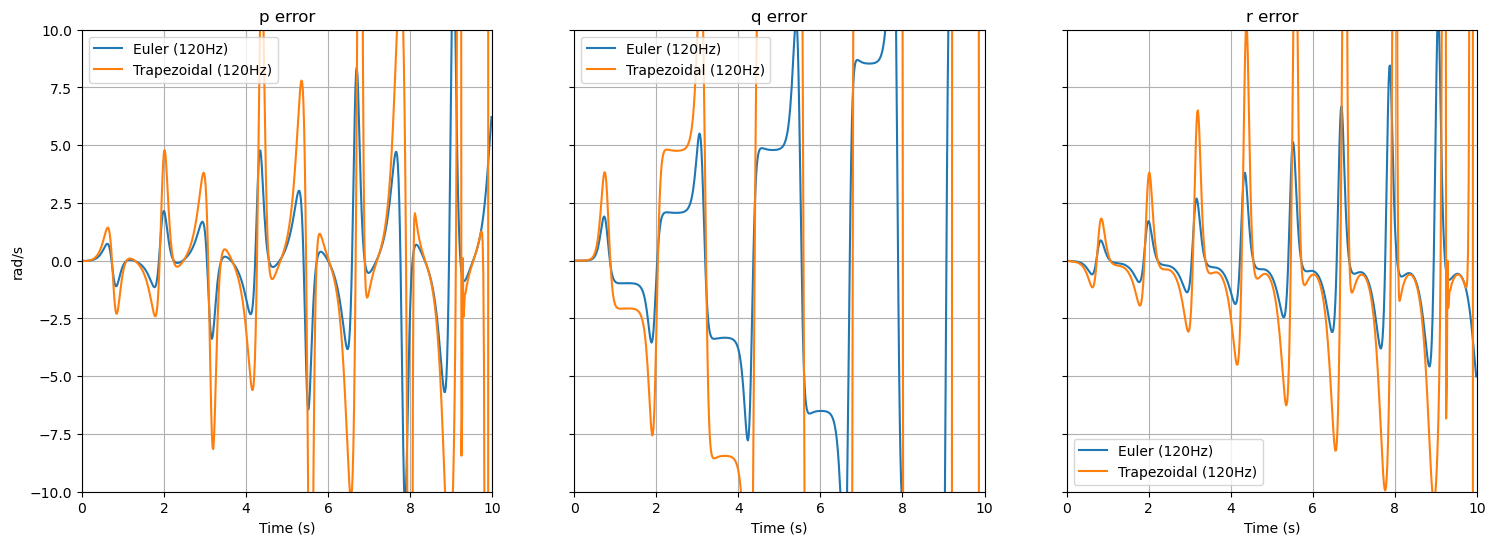

In [12]:
plot_rotation_rate_errors(results, exact, y_range=(-10,10), name_col=1)

### Adams-Bashforth methods

Given that the Euler and trapezoidal methods behave poorly. We will now evaluate how the Adams-Bashforth behave.

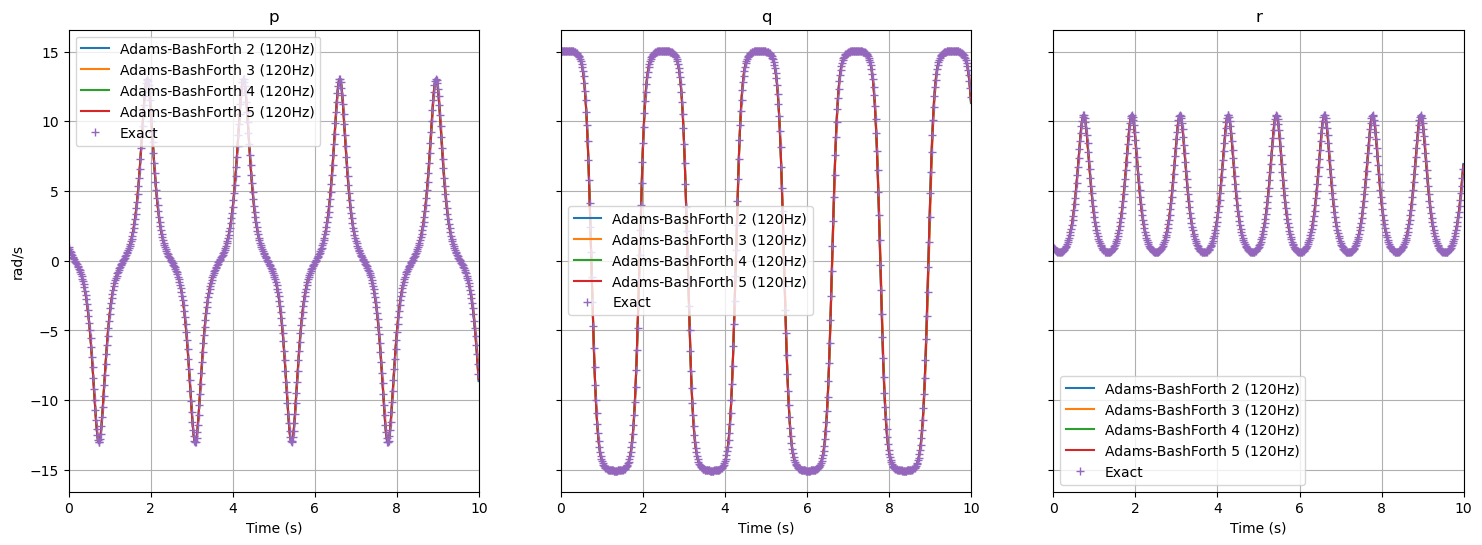

In [13]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH2, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH3, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH4, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rates(results, exact, name_col=1)

The explicit Adams-Bahforth method bring significant improvements over Euler and the trapezoidal methods. They are behaving well over the 10 simulated seconds with no obvious sign of frequency drift or ampltiude divergence.

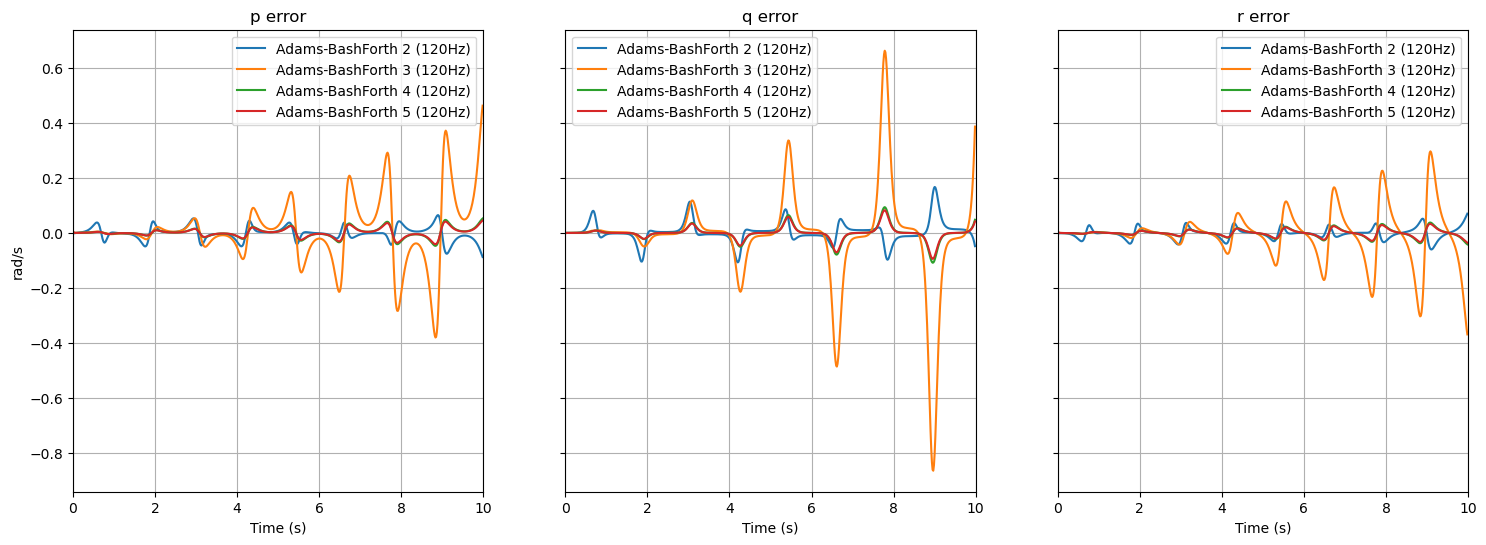

In [14]:
plot_rotation_rate_errors(results, exact, name_col=1)

Surprinsingly, the Adams-Bashforth scheme of the 3rd order is performing significantly worse than Adams-Bashforth of the 2nd order. The 4th and 5th order schemes cannot be distinguished.

If the step size is halved, the error is diminished but the hierarchy is not changed: the 3rd order is giving the larger errors, followed by 2nd order. There again, the 4th and 5th order cannot be distinguished.

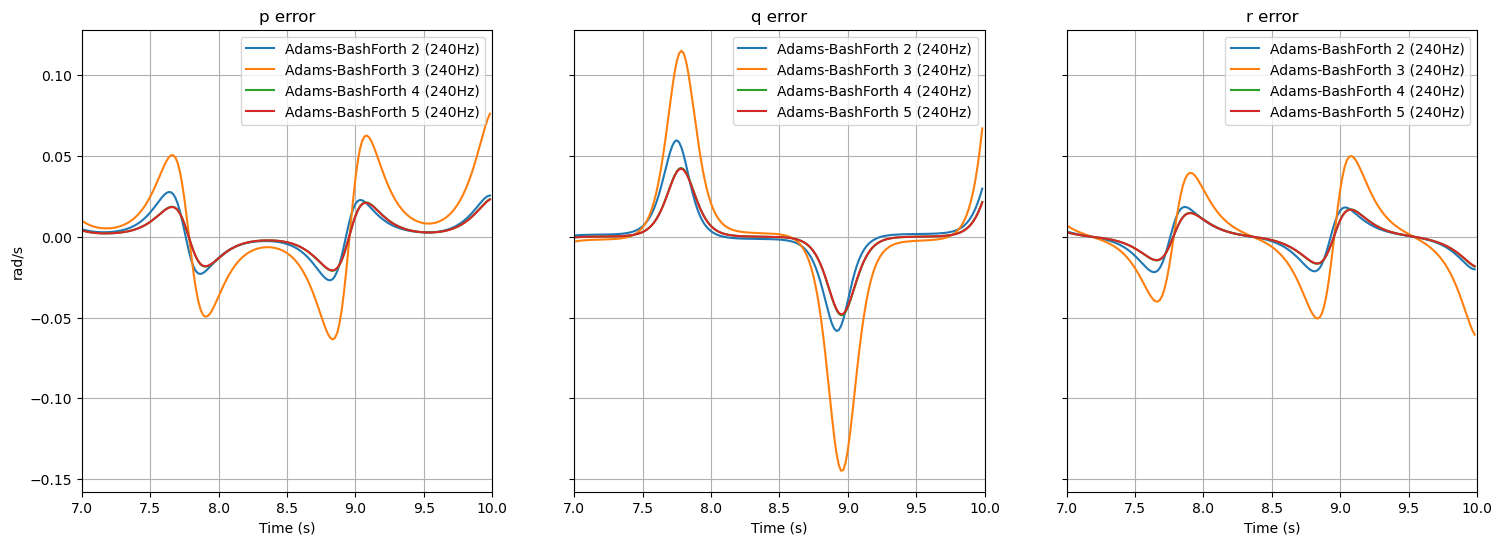

In [72]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH2, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH3, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH4, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 240))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rate_errors(results, exact, time_range=(7, 10),name_col=1)

Now we halving the time steps several times using the Adams-Bashforth scheme of the 5th order. It appears clearly that at some point the error is no longer dimishing as would be expected. This tends to show that there exists an error that is not due to the integration schemes precision.

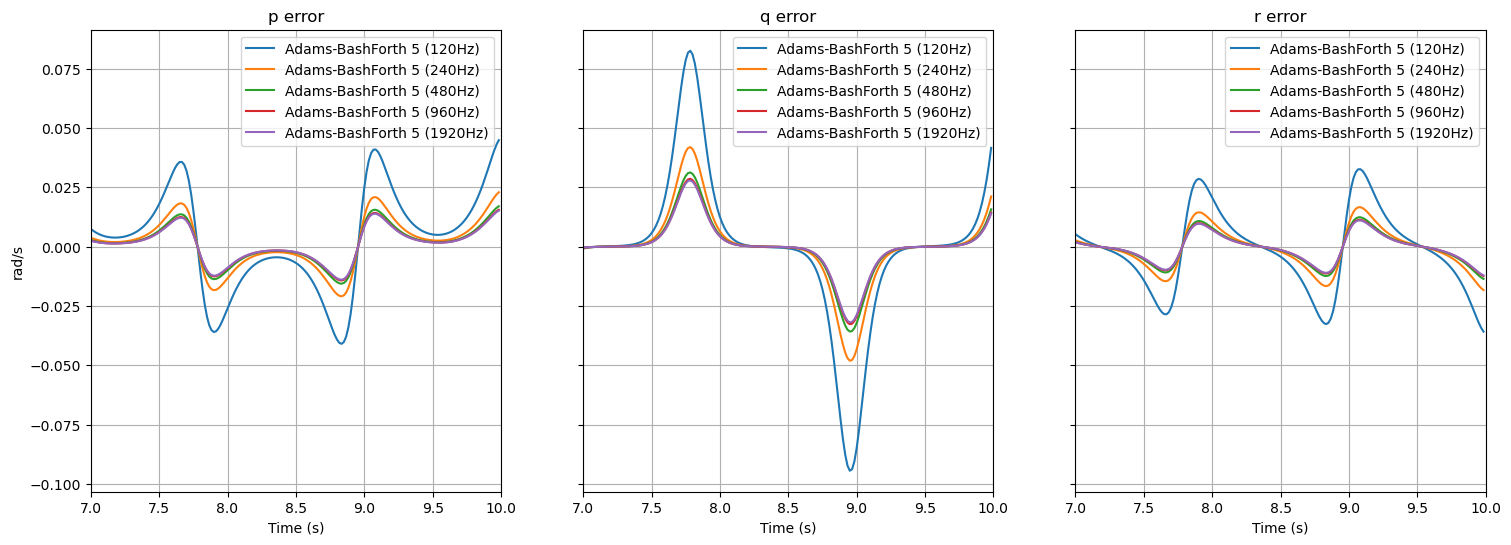

In [71]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 240),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 480),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 960),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 1920))

results = run_rotations_simulations(integrators, t_final)
plot_rotation_rate_errors(results, exact, time_range=(7,10),name_col=1)

## Euler Angles

### Plotting Euler angles

This function displays the Euler angles (Roll, Pitch, Yaw) over time for the various integration methods.

In [36]:
def plot_euler_angles(results, exact_data, *, time_range=(0, t_final), name_col=0):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 8), sharex=True)

    for i in range(len(results.methods)):
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"
        ax1.plot(results.times[i, :], results.roll[i, :], label=label)
        ax2.plot(results.times[i, :], results.pitch[i, :], label=label)
        ax3.plot(results.times[i, :], results.yaw[i, :], label=label)

    ax1.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 13], '+', label='Exact')
    ax2.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 14], '+', label='Exact')
    ax3.plot(exact_data.iloc[:, 0], exact_data.iloc[:, 15], '+', label='Exact')

    ax1.set_ylabel("roll (rad)")
    ax2.set_ylabel("pitch (rad)")
    ax3.set_ylabel("yaw (rad)")
    ax3.set_xlabel("Time (s)")
    ax3.set_xlim(time_range)

    for ax in (ax1, ax2, ax3):
        ax.grid()
        ax.legend()

    plt.show()

### Helper function for angle modulo

This utility function wraps angles into the $[-\pi, \pi]$ range to clean the apparent errors where an angle oscillates between 0 and $2\pi$.

In [37]:
def mod_2pi(x):
    return (x + np.pi) % (2.0 * np.pi) - np.pi

### Plotting Euler angle errors

This function computes and visualizes the errors in Euler angles, ensuring that angular wrap-around is properly handled.

In [41]:
def plot_euler_angle_errors(results, exact_data, *, name_col=0):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    nvalues = len(exact_data)

    for i in range(len(results.methods)):
        step = int(results.methods[i][2] / freq_exact)
        label = f"{method_names[results.methods[i][name_col]]} ({results.methods[i][2]:.0f}Hz)"

        err_roll = mod_2pi(results.roll[i, :step*nvalues:step] - exact_data.iloc[:, 13])
        err_pitch = mod_2pi(results.pitch[i, :step*nvalues:step] - exact_data.iloc[:, 14])
        err_yaw = mod_2pi(results.yaw[i, :step*nvalues:step] - exact_data.iloc[:, 15])

        ax1.plot(exact_data.iloc[:, 0], err_roll, label=label)
        ax2.plot(exact_data.iloc[:, 0], err_pitch, label=label)
        ax3.plot(exact_data.iloc[:, 0], err_yaw, label=label)

    for ax, title in zip((ax1, ax2, ax3), ("roll error", "pitch error", "yaw error")):
        ax.set_title(title)
        ax.set_xlabel("Time (s)")
        ax.legend()
        ax.grid()

    ax1.set_ylabel("rad")
    plt.show()

### Evaluating Adams-Bashforth

From the analyses made on the rotation rates, the 5th order Adams-Bashforth scheme is selected to compute the rotation rates. Below are displayed the computation of the Euler angles for the Adams-Bashforth schemes on the last 2 seconds of the simulation.

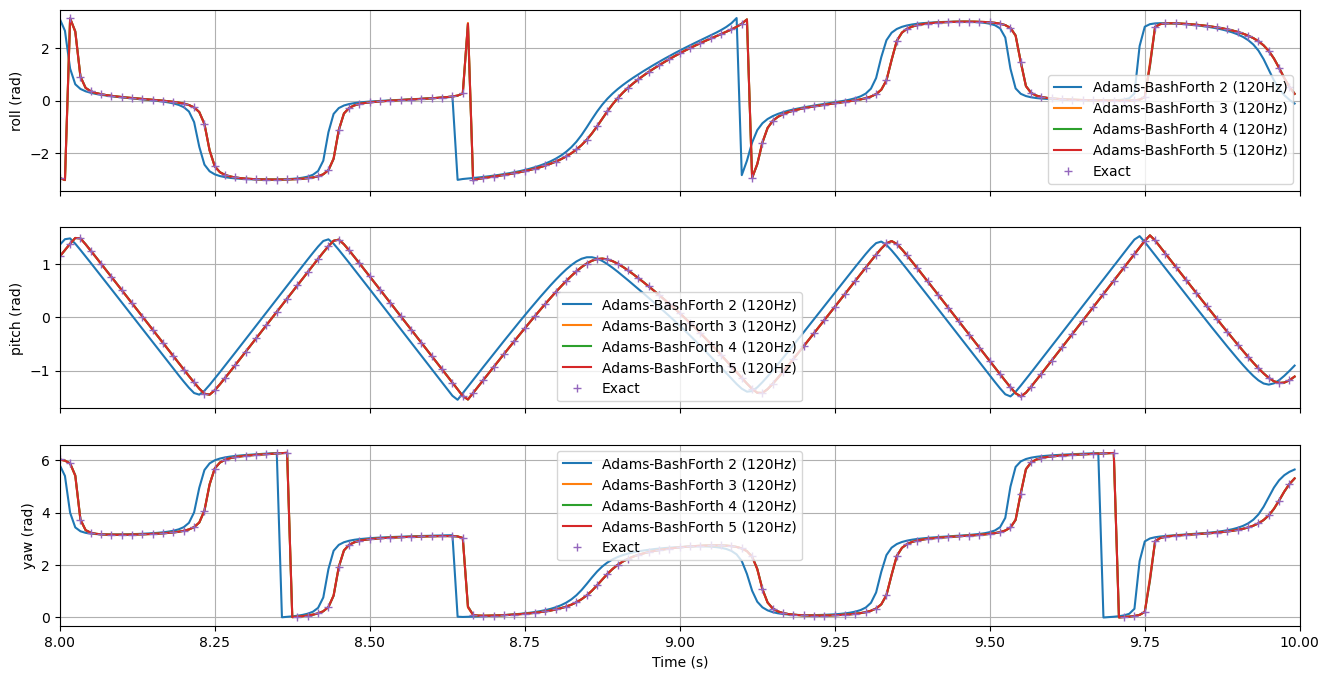

In [42]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH2, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angles(results, exact, time_range=(8,10))

Since the 2nd order Adams-Bashforth scheme is performing notably worse than the other Adams-Bashforth schemes. From now on, we will only focus on the Adams-Bashforth schemes of 3rd, 4th and 5th order. Below are the error of these schemes with respect to the exact solution.

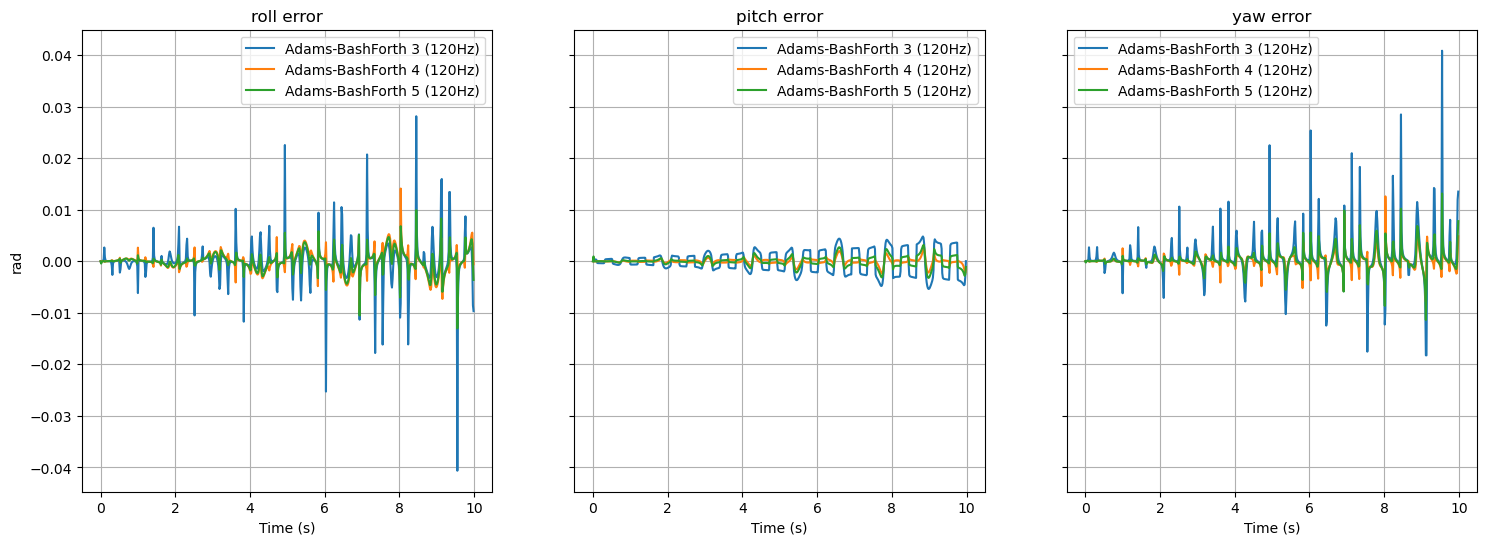

In [43]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

JSBsim includes for the computation of the vehicle attitude some methods specifically designed for the integration of quaternions ODE:
- Buss methods of the first and second order according to the paper *Accurate and Efficient Simulation of Rigid Body Rotations*, Buss S., 2001
- Local linearization according to the NASA technical note TN D-7347 *Development and Application of a Local Linearization Algorithm for the Integration of Quaternion Rate Equations in Real-Time Flight Simulation Problems*, Barker E. Jr, Bowles R., Williams L, 1973

First, we start by comparing the Buss scheme of first order to the 2nd order Adams-Bashforth schemes.

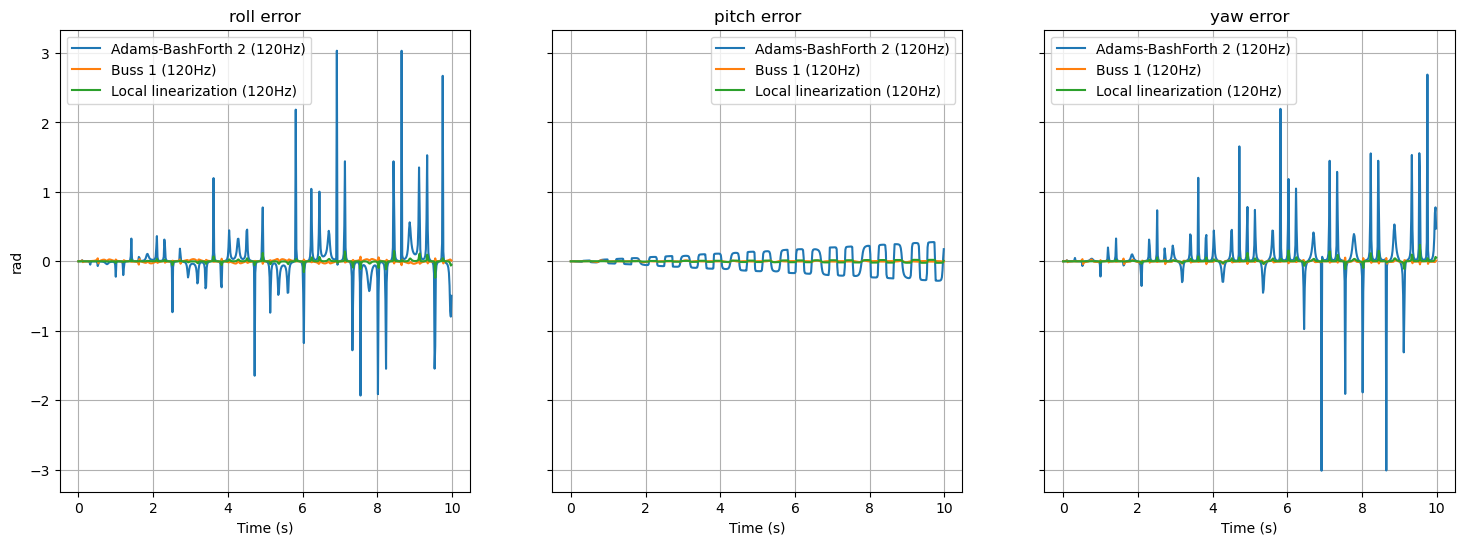

In [52]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH2, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS1, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.LOCAL_LINEARIZATION, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

The Buss scheme of the first order and NASA's local linearization behave much better than Adams-Bashforth of the 2nd order so we will now compare to the Adams-Bashforth schemes of the 3rd order.

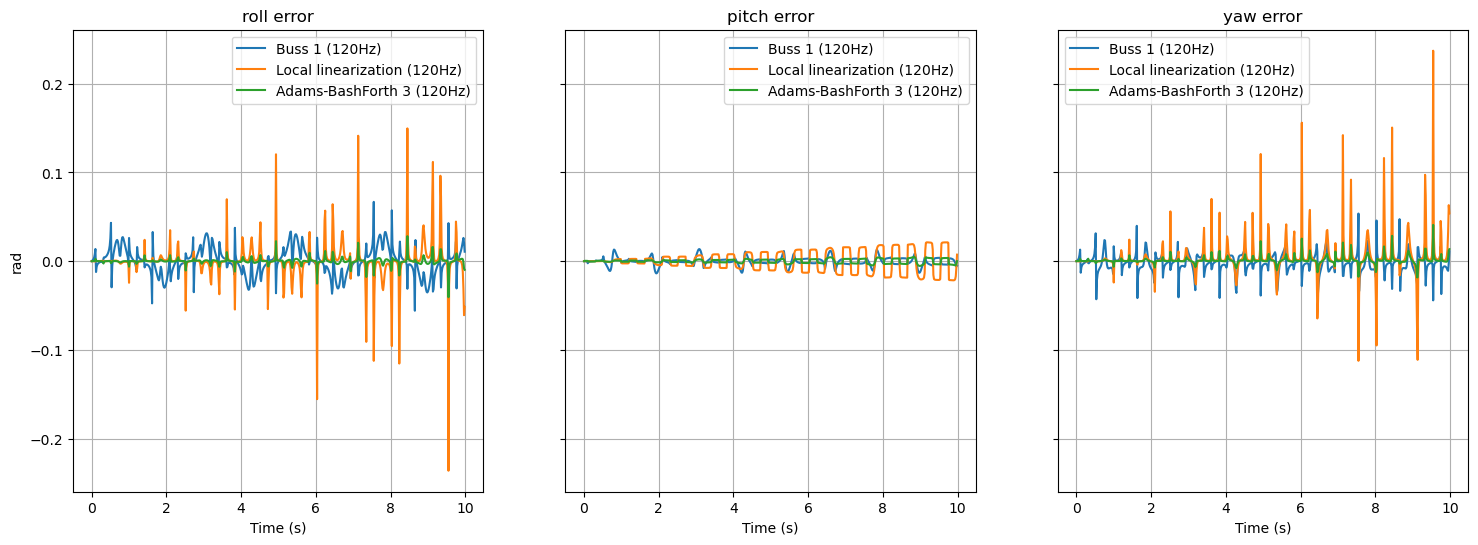

In [59]:
integrators =  ((ODE_methods.BUSS1, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.LOCAL_LINEARIZATION, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

Both the Buss scheme of the first order and local linearization are performing worse than Adams-Bashforth of the 3rd order with Buss performing slightly better than local linearization.

Let's see how the Buss scheme of the 2nd order performs with respect to the Adams-Bashforth schemes of the 3rd, 4th and 5th order.

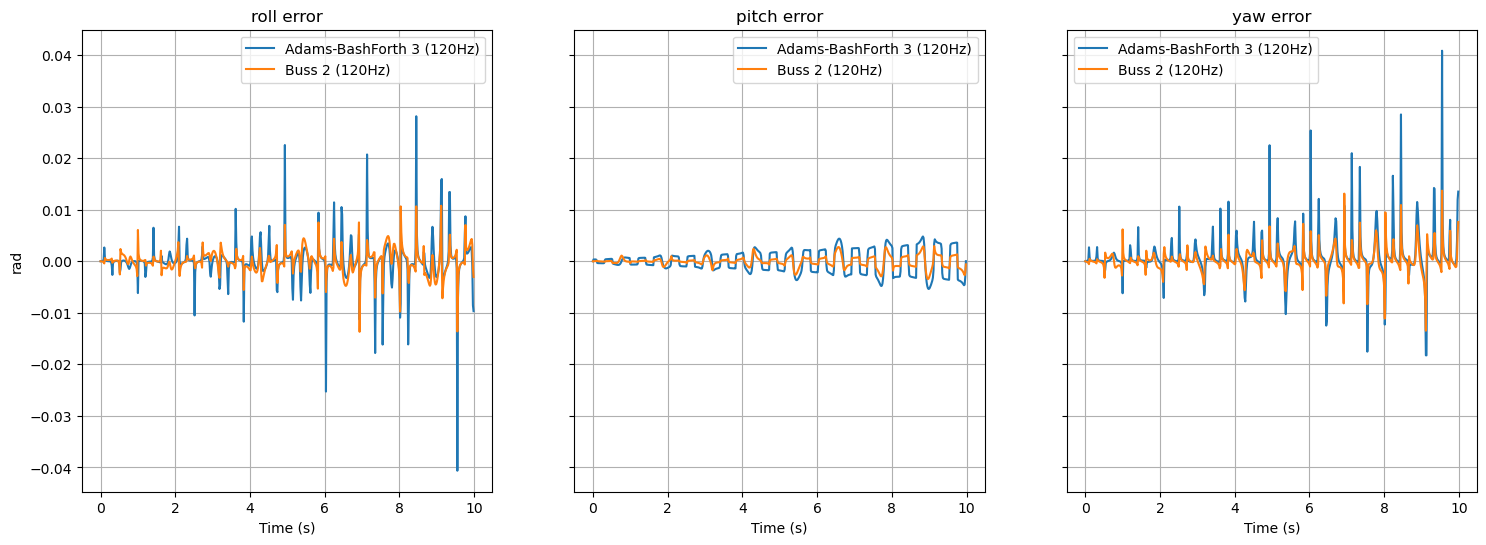

In [57]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH3, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS2, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

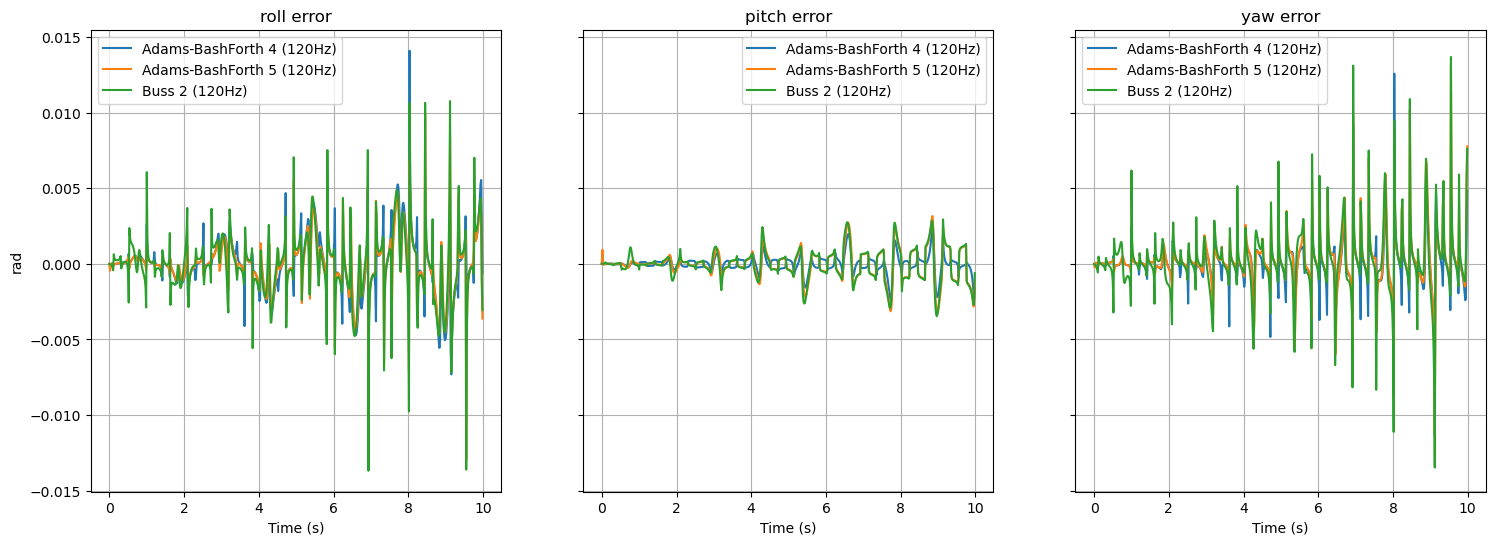

In [61]:
integrators =  ((ODE_methods.ADAMS_BASHFORTH4, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.ADAMS_BASHFORTH5, ODE_methods.ADAMS_BASHFORTH5, 120),
                (ODE_methods.BUSS2, ODE_methods.ADAMS_BASHFORTH5, 120))

results = run_rotations_simulations(integrators, t_final)
plot_euler_angle_errors(results, exact)

Generally speaking Buss 2 performs better than Adams-Bashforth of the 3rd order and in the same precision than Adams-Bashforth of the 4th and 5th order.